# Analyzing Experiment Results
This code is intended to use results in the `saved_selection_data.csv` and `saved_yolked_data.csv` to generate plots and otherwise interpret the results of the experiments run.

In [40]:
from dataclasses import dataclass
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [52]:
@dataclass(frozen=True,slots=True)
class experiment_metadata:
    UUID: str
    "A UUID to identify the experiment"
    category_boundary: str
    "The boundary between the two categories in the experiment (save vs. not)"
    learning_stimuli: list[list[float]]
    "All stimuli selected from learning. This is a float as a string."
    testing_stimuli: list[list[float]]
    "All stimuli used for testing. This is a float as a string. First axis should be the same size as learning_stimuli"
    testing_individual_results: list[list[bool]]
    "The categorizations made by the participant for each of the corresponting stimuli. <br>True='safe'=`> category boundary`  <br>False='not safe' = `< category boundary`"
    testing_individual_correctness: list[list[bool]]
    "Whether the individual correctly classified the testing stimuli. If True they categorized correctly."
    testing_round_correctness: list[float]
    "Combines correctness by round, giving the percentage correct"
    testing_round_certainties: list[int]
    "Reports the participant certainty ratings (0-4) by round"
    testing_overall_correctness: float
    "Combines correctness for the entirety of all tests, giving overall percentage correct"

def load_experiments(
    selection_path: Path,
    yolked_path: Path,
) -> tuple[list[experiment_metadata], list[experiment_metadata]]:
    "Returns all results of experiments as objects. form: (list_of_selection_results, list_of_yolked_results)."
    def _parse_row(row) -> experiment_metadata:
        return experiment_metadata(
            UUID=row["UUID"],
            category_boundary=str(row["category_boundary"]),
            learning_stimuli=ast.literal_eval(row["learning_stimuli"]),
            testing_stimuli=ast.literal_eval(row["testing_stimuli"]),
            testing_individual_results=ast.literal_eval(row["testing_individual_results"]),
            testing_individual_correctness=ast.literal_eval(row["testing_individual_correctness"]),
            testing_round_correctness=ast.literal_eval(row["testing_round_correctness"]),
            testing_round_certainties=ast.literal_eval(row["testing_round_certainties"]),
            testing_overall_correctness=float(row["testing_overall_correctness"]),
        )

    selection_df = pd.read_csv(selection_path)
    yolked_df = pd.read_csv(yolked_path)

    return (
        [_parse_row(row) for _, row in selection_df.iterrows()],
        [_parse_row(row) for _, row in yolked_df.iterrows()],
    )

def pair_by_UUID(experiments:tuple[list[experiment_metadata], list[experiment_metadata]])->list[tuple[experiment_metadata,experiment_metadata]]:
    "Accepts (list_of_selection_results, list_of_yolked_results), outputs [(selection,yoked),...]paired by uuids"
    selection,yoked = experiments

    result: list[tuple[experiment_metadata,experiment_metadata]] = []

    for s in selection:
        for y in yoked:
            if s.UUID == y.UUID:
                result.append((s,y))
                break

    return result

def extract_accuracies_by_block(experiments:list[experiment_metadata])->list[list[float]]:
    results: list[list[float]] = []

    for e in experiments:
        num_block_exp = len(e.testing_round_correctness)
        num_block_exist = len(results)
        num_block_diff = max(0, num_block_exp - num_block_exist)
        for _ in range(num_block_diff): results.append([])

        for i, acc in enumerate(e.testing_round_correctness):
            results[i].append(acc)
    
    return results

In [42]:
def plot_experiment_pair(selection: experiment_metadata, yoked: experiment_metadata) -> None:
    """Plot a selection and yoked experiment side-by-side, showing the full trial sequence."""
    fig, (ax_sel, ax_yok) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

    def _plot_single(ax, exp: experiment_metadata, title: str) -> int:
        y = 0
        ytick_positions = []
        ytick_labels = []

        for round_idx in range(len(exp.learning_stimuli)):
            # Thick gridline on L rows — label sits on it
            ax.axhline(y=y, color='gray', linestyle='-', linewidth=1.5, alpha=0.55, zorder=1)
            for stim in exp.learning_stimuli[round_idx]:
                ax.plot(stim, y, 'D', color='steelblue', markersize=8, zorder=3)
            ytick_positions.append(y)
            ytick_labels.append(f'L{round_idx}')
            y += 1

            # Thin gridline on T rows — label sits on it
            ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
            for stim_idx, stim in enumerate(exp.testing_stimuli[round_idx]):
                correct = exp.testing_individual_correctness[round_idx][stim_idx]
                if correct:
                    ax.plot(stim, y, 'o', color='green', markersize=8, zorder=3)
                else:
                    ax.plot(stim, y, 'x', color='red', markersize=10, markeredgewidth=2, zorder=3)
            ytick_positions.append(y)
            ytick_labels.append(f'T{round_idx}')
            y += 1

        ax.axvline(x=float(exp.category_boundary), color='black', linestyle='--', linewidth=1.5)
        ax.set_xlim(0, 1)
        ax.set_yticks(ytick_positions)
        ax.set_yticklabels(ytick_labels)
        ax.set_xlabel("Stimulus value")
        ax.set_title(title)
        ax.grid(axis='x', alpha=0.3)  # vertical gridlines only; horizontal drawn explicitly above
        return y

    total = _plot_single(ax_sel, selection, "Selection")
    _plot_single(ax_yok, yoked, "Yoked")

    ax_sel.set_ylim(total - 0.5, -0.5)
    ax_sel.set_ylabel("Round  (L = Learning, T = Testing)")

    fig.suptitle(f"UUID: {selection.UUID}", fontsize=9)

    legend_handles = [
        mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='steelblue', markersize=8, label='Learning stimulus'),
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Test: correct'),
        mlines.Line2D([0], [0], marker='x', color='red', markersize=10, markeredgewidth=2, label='Test: incorrect'),
        mlines.Line2D([0], [0], linestyle='--', color='black', label='Category boundary'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0))
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.show()

In [43]:
def plot_experiment_pair_stacked(selection: experiment_metadata, yoked: experiment_metadata) -> None:
    """Single plot interleaving L / S (selector test) / Y (yoked test) rows per round."""
    fig, ax = plt.subplots(figsize=(10, 10))

    y = 0
    ytick_positions = []
    ytick_labels = []

    for round_idx in range(len(selection.learning_stimuli)):
        # L row — thick line, shared learning stimuli
        ax.axhline(y=y, color='gray', linestyle='-', linewidth=1.5, alpha=0.55, zorder=1)
        for stim in selection.learning_stimuli[round_idx]:
            ax.plot(stim, y, 'D', color='steelblue', markersize=8, zorder=3)
        ytick_positions.append(y)
        ytick_labels.append(f'L{round_idx}')
        y += 1

        # S row — intermediate grey band + selector test results
        ax.axhspan(y - 0.45, y + 0.45, color='lightgrey', alpha=0.3, zorder=0)
        ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
        for stim_idx, stim in enumerate(selection.testing_stimuli[round_idx]):
            correct = selection.testing_individual_correctness[round_idx][stim_idx]
            if correct:
                ax.plot(stim, y, 'o', color='green', markersize=8, zorder=3)
            else:
                ax.plot(stim, y, 'x', color='red', markersize=10, markeredgewidth=2, zorder=3)
        ytick_positions.append(y)
        ytick_labels.append(f'S{round_idx}')
        y += 1

        # Y row — full grey band + yoked test results
        ax.axhspan(y - 0.45, y + 0.45, color='lightgrey', alpha=0.6, zorder=0)
        ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
        for stim_idx, stim in enumerate(yoked.testing_stimuli[round_idx]):
            correct = yoked.testing_individual_correctness[round_idx][stim_idx]
            if correct:
                ax.plot(stim, y, 'o', color='green', markersize=8, zorder=3)
            else:
                ax.plot(stim, y, 'x', color='red', markersize=10, markeredgewidth=2, zorder=3)
        ytick_positions.append(y)
        ytick_labels.append(f'Y{round_idx}')
        y += 1

    ax.axvline(x=float(selection.category_boundary), color='black', linestyle='--', linewidth=1.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(y - 0.5, -0.5)
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels)
    ax.set_xlabel("Stimulus value")
    ax.set_ylabel("Round  (L = Learning, S = Selector Test, Y = Yoked Test)")
    ax.grid(axis='x', alpha=0.3)

    fig.suptitle(f"UUID: {selection.UUID}", fontsize=9)

    legend_handles = [
        mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='steelblue', markersize=8, label='Learning stimulus'),
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Test: correct'),
        mlines.Line2D([0], [0], marker='x', color='red', markersize=10, markeredgewidth=2, label='Test: incorrect'),
        mlines.Line2D([0], [0], linestyle='--', color='black', label='Category boundary'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0))
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.show()

In [46]:
def plot_experiment_grid(
    pairs: list[tuple[experiment_metadata, experiment_metadata]],
    ncols: int = 2,
    nrows: int = 5,
) -> None:
    """Tile plot_experiment_pair_stacked plots in a grid. Defaults to 2 wide x 5 tall."""
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 7, nrows * 3.5),
        sharey=True, sharex=True,
    )
    axes_flat = axes.flatten()

    ytick_positions: list[int] = []
    ytick_labels: list[str] = []
    total_y = 0

    for idx, (selection, yoked) in enumerate(pairs[:nrows * ncols]):
        ax = axes_flat[idx]
        y = 0
        ytick_pos: list[int] = []
        ytick_lab: list[str] = []

        for round_idx in range(len(selection.learning_stimuli)):
            # L row
            ax.axhline(y=y, color='gray', linestyle='-', linewidth=1.5, alpha=0.55, zorder=1)
            for stim in selection.learning_stimuli[round_idx]:
                ax.plot(stim, y, 'D', color='steelblue', markersize=5, zorder=3)
            ytick_pos.append(y)
            ytick_lab.append(f'L{round_idx}')
            y += 1

            # S row
            ax.axhspan(y - 0.45, y + 0.45, color='lightgrey', alpha=0.3, zorder=0)
            ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
            for stim_idx, stim in enumerate(selection.testing_stimuli[round_idx]):
                correct = selection.testing_individual_correctness[round_idx][stim_idx]
                if correct:
                    ax.plot(stim, y, 'o', color='green', markersize=5, zorder=3)
                else:
                    ax.plot(stim, y, 'x', color='red', markersize=7, markeredgewidth=1.5, zorder=3)
            ytick_pos.append(y)
            ytick_lab.append(f'S{round_idx}')
            y += 1

            # Y row
            ax.axhspan(y - 0.45, y + 0.45, color='lightgrey', alpha=0.8, zorder=0)
            ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
            for stim_idx, stim in enumerate(yoked.testing_stimuli[round_idx]):
                correct = yoked.testing_individual_correctness[round_idx][stim_idx]
                if correct:
                    ax.plot(stim, y, 'o', color='green', markersize=5, zorder=3)
                else:
                    ax.plot(stim, y, 'x', color='red', markersize=7, markeredgewidth=1.5, zorder=3)
            ytick_pos.append(y)
            ytick_lab.append(f'Y{round_idx}')
            y += 1

        ax.axvline(x=float(selection.category_boundary), color='black', linestyle='--', linewidth=1.0)
        ax.set_title(selection.UUID, fontsize=6)
        ax.grid(axis='x', alpha=0.3)

        if idx == 0:
            ytick_positions, ytick_labels, total_y = ytick_pos, ytick_lab, y

    # Set ticks once — sharey propagates limits and tick positions to all axes
    axes_flat[0].set_yticks(ytick_positions)
    axes_flat[0].set_yticklabels(ytick_labels)
    axes_flat[0].set_ylim(total_y - 0.5, -0.5)
    axes_flat[0].set_xlim(0, 1)

    # Hide any unused subplot slots
    for idx in range(len(pairs), nrows * ncols):
        axes_flat[idx].set_visible(False)

    # Axis labels only on border subplots
    for col in range(ncols):
        axes[-1, col].set_xlabel("Stimulus value")
    for row in range(nrows):
        axes[row, 0].set_ylabel("Round")

    legend_handles = [
        mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='steelblue', markersize=6, label='Learning stimulus'),
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=6, label='Test: correct'),
        mlines.Line2D([0], [0], marker='x', color='red', markersize=8, markeredgewidth=1.5, label='Test: incorrect'),
        mlines.Line2D([0], [0], linestyle='--', color='black', label='Category boundary'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0))
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

In [51]:
selection_data, yolked_data = load_experiments(
    selection_path=Path("./saved_selection_data.csv"),
    yolked_path=Path("./saved_yolked_data.csv")
    )

pairs = pair_by_UUID((selection_data,yolked_data))

print(extract_accuracies_by_block(selection_data))
# print(selection_data[0])
# print([[m.UUID for m in p] for p in pairs])
# print(selection_data[0].testing_round_certainties)
# print([c+1 for c in selection_data[0].testing_round_certainties]) # Use list comprehension to increment all entries in a list
# print([s.testing_round_certainties for s in selection_data]) # Use list comprehension to extract all certainties into one 2D list.

None


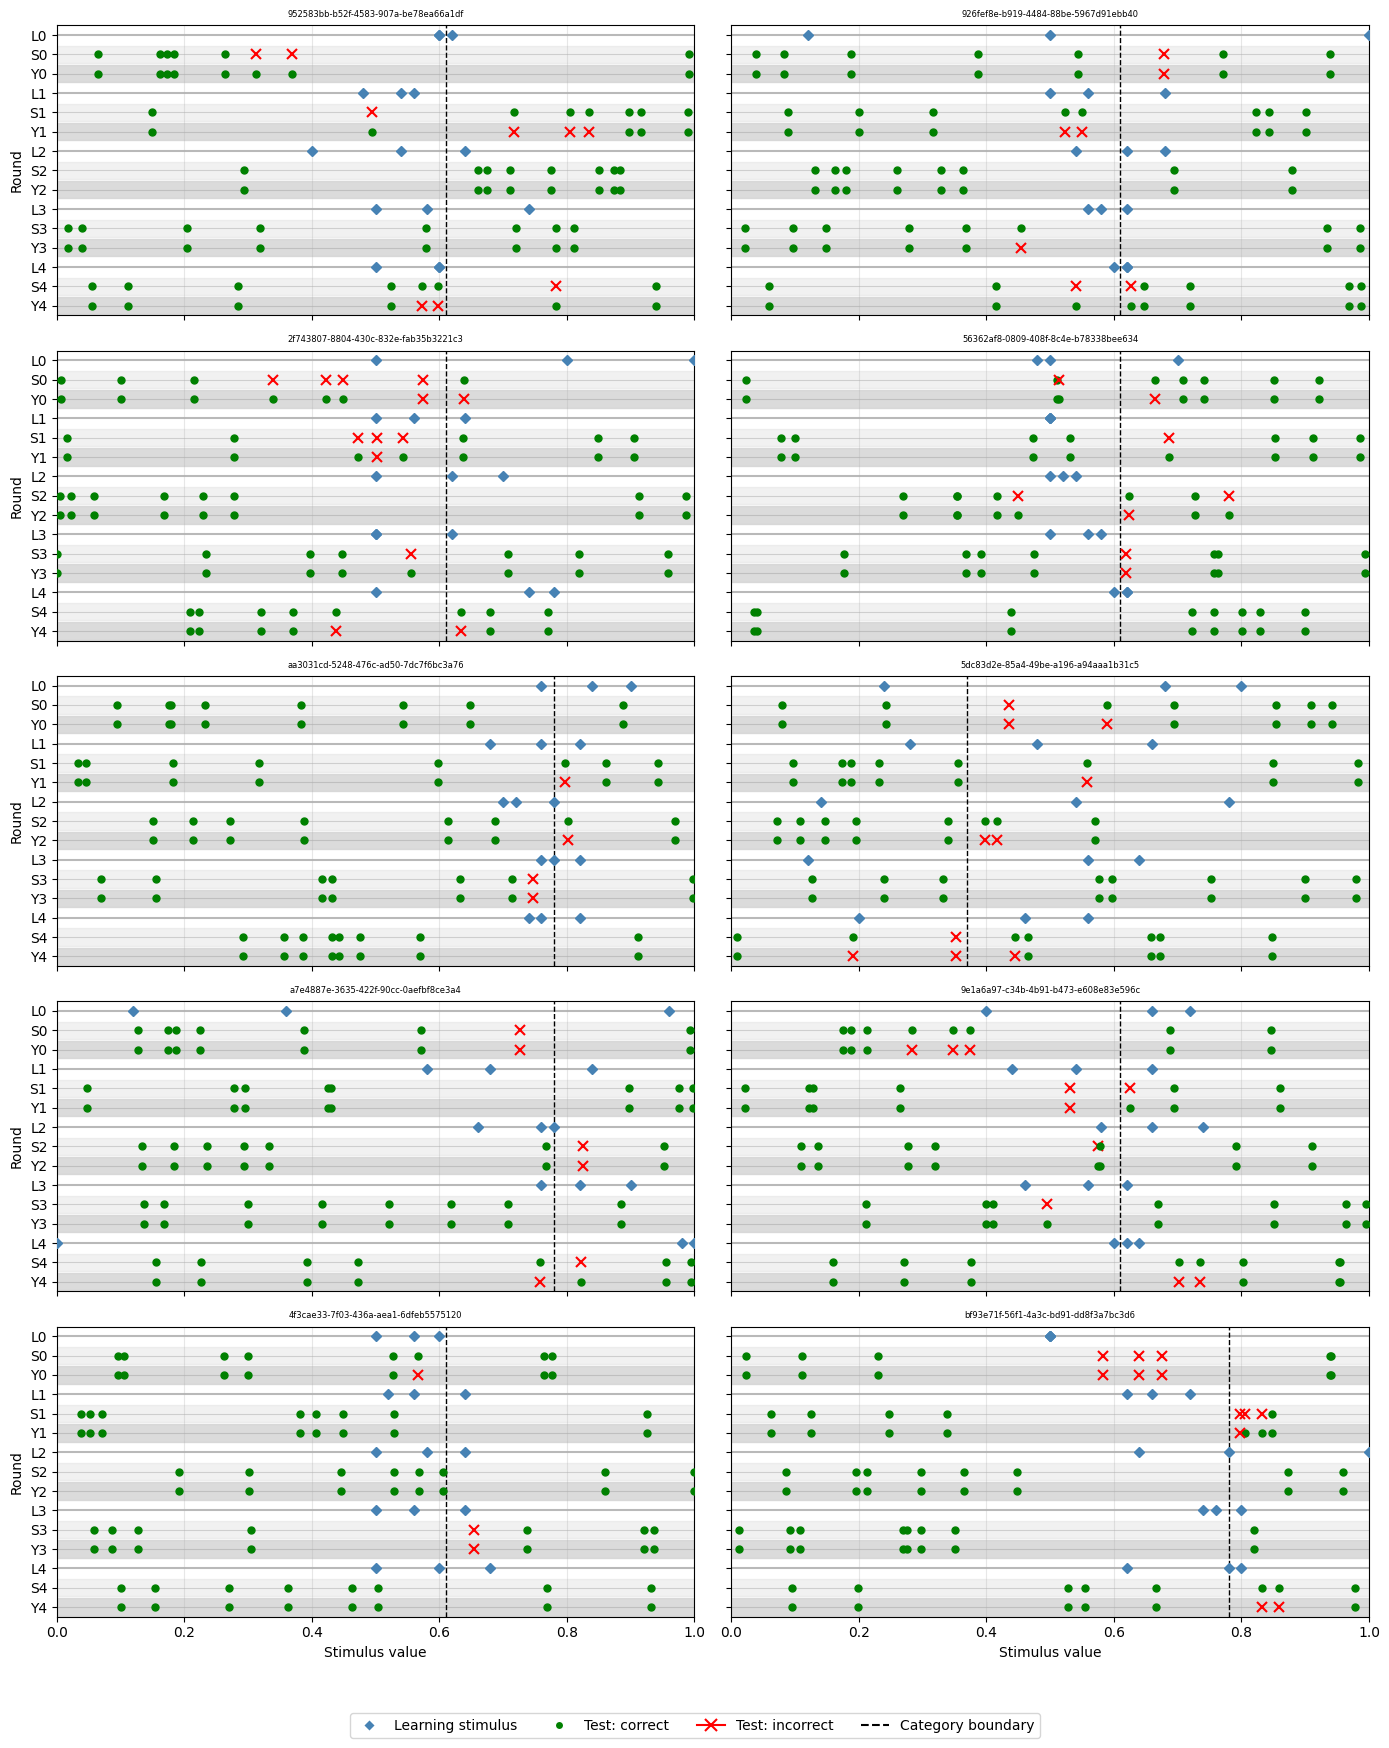

In [47]:
for p in pairs:
    pass
    # plot_experiment_pair(
    #     selection=p[0],
    #     yoked=p[1]
    # )
    # plot_experiment_pair_stacked(
    #     selection=p[0],
    #     yoked=p[1]
    # )
plot_experiment_grid(
    pairs=pairs,
    ncols=2,
    nrows=5
)

In [49]:
def plot_accuracy_by_block(
    selection_accuracies: list[list[float]],
    yoked_accuracies: list[list[float]],
) -> None:
    """
    Plot mean accuracy ± SEM per test block for selection and yoked experiments.

    Each outer list index is a test block; the inner list contains one accuracy
    value per experiment. Build the inputs like:
        [[exp.testing_round_correctness[b] for exp in selection_data] for b in range(n_blocks)]
    """
    def _mean_sem(data: list[list[float]]) -> tuple[np.ndarray, np.ndarray]:
        means, sems = [], []
        for block in data:
            arr = np.array(block)
            means.append(arr.mean())
            sems.append(arr.std(ddof=1) / np.sqrt(len(arr)))
        return np.array(means), np.array(sems)

    sel_means, sel_sems = _mean_sem(selection_accuracies)
    yok_means, yok_sems = _mean_sem(yoked_accuracies)
    x = np.arange(1, len(selection_accuracies) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(x, sel_means, yerr=sel_sems,
                label='Selection', marker='o', linestyle='-',
                color='black', capsize=3, linewidth=1.5)
    ax.errorbar(x, yok_means, yerr=yok_sems,
                label='Yoked', marker='o', linestyle='--',
                color='gray', capsize=3, linewidth=1.5)

    ax.set_xlabel("Test block")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(x)
    ax.set_xlim(0.5, len(selection_accuracies) + 0.5)
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.set_title("Accuracy by test block")
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

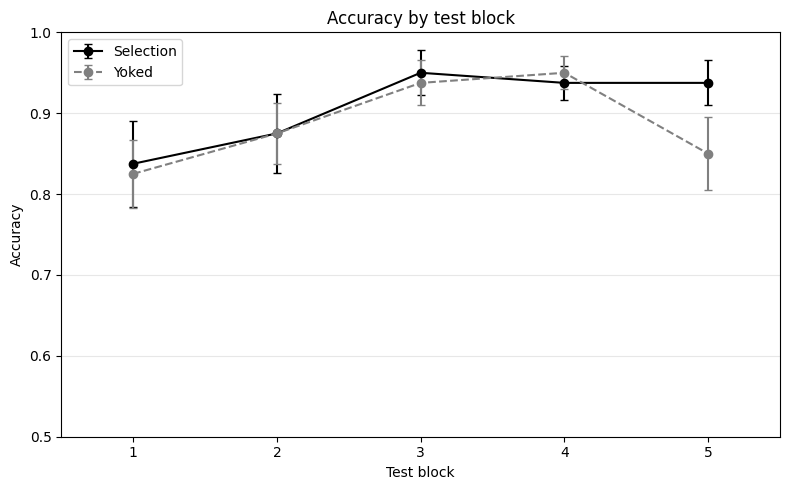

In [53]:
plot_accuracy_by_block(
    selection_accuracies=extract_accuracies_by_block(selection_data),
    yoked_accuracies=extract_accuracies_by_block(yolked_data)
)